In [2]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
sns.set_theme(style="darkgrid")

print("import done!")

import done!


In [4]:
train_df = pd.read_csv('../data/twitter_training.csv', header=None)
val_df = pd.read_csv('../data/twitter_validation.csv', header=None)

train_df.columns = ['id','entity','sentiment','text']
val_df.columns = ['id', 'entity', 'sentiment', 'text']

print("Train shape :", train_df.shape)
print("Val shape :", val_df.shape)

Train shape : (74682, 4)
Val shape : (1000, 4)


In [5]:
print("== TRAIN DATA INFO ==")
print(train_df.info())
print("\n=== MISSING VALUES ===")
print(train_df.isnull().sum())
print("\n=== SENTIMENT CLASSES ===")
print(train_df['sentiment'].value_counts())

== TRAIN DATA INFO ==
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB
None

=== MISSING VALUES ===
id             0
entity         0
sentiment      0
text         686
dtype: int64

=== SENTIMENT CLASSES ===
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


C:\Users\ankit\AppData\Local\Temp\ipykernel_3596\3952695262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='sentiment',


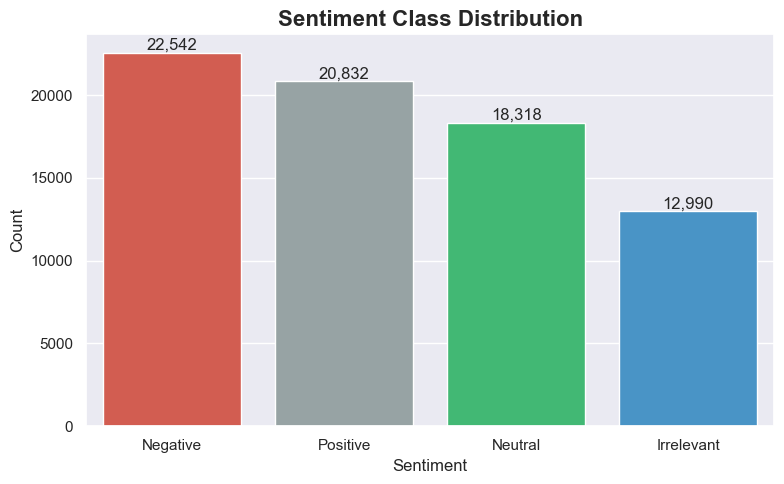

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='sentiment', 
                   palette=['#e74c3c','#95a5a6','#2ecc71','#3498db'],
                   order=train_df['sentiment'].value_counts().index)

plt.title('Sentiment Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
print(f"Before cleaning : {train_df.shape}")

train_df = train_df.dropna(subset=['text'])
val_df = val_df.dropna(subset=['text'])

train_df = train_df.drop_duplicates(subset=['text'])

print(f"After cleaning: {train_df.shape}")
print(f"rows removed: {74682 - train_df.shape[0]}")

Before cleaning : (74682, 4)
After cleaning: (69491, 4)
rows removed: 5191


In [9]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    token = text.split()
    tokens = text.split()
    token = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)

print(" Text cleaning done")
train_df[['text', 'clean_text']].head(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...


TypeError: WordNetLemmatizer.lemmatize() missing 1 required positional argument: 'word'